## Objetivo y contexto
Modelar L usando M y T con features polinomiales e interacción; solo NumPy/Matplotlib.

In [67]:
# Importar Bibliotecas Necesarias
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## Importaciones
Librerías mínimas.

In [68]:
# Definir el Dataset (M, T, L)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])
print(f"n muestras: {M.size}")

n muestras: 10


## 1) Dataset visualization
Plot L vs M y encode T (color).

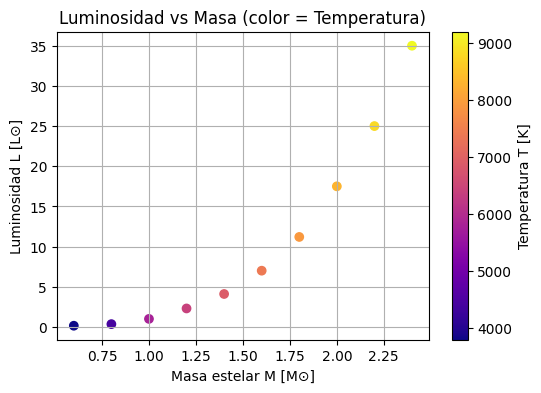

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(M, L, c=T, cmap='plasma')
cbar = plt.colorbar(sc)
cbar.set_label('Temperatura T [K]')
ax.set_title('Luminosidad vs Masa (color = Temperatura)')
ax.set_xlabel('Masa estelar M [M⊙]')
ax.set_ylabel('Luminosidad L [L⊙]')
plt.show()

## 2) Feature engineering
Build X con NumPy vectorización.

In [70]:
# Escalado de temperatura y construcción de X completa
T_k = T / 1000.0
X_full = np.column_stack([M, T_k, M**2, M * T_k])

## 3) Loss and gradients (vectorized)
Implement MSE y gradientes w.r.t. w y b.

In [71]:
# Hipótesis, pérdida y gradientes (vectorizados)
def predict_X(X, w, b):
    return X @ w + b

def mse(y_hat, y):
    return np.mean((y_hat - y)**2)

def gradients(X, y, w, b):
    n = X.shape[0]
    err = (X @ w + b) - y
    dw = (2.0 / n) * (X.T @ err)
    db = (2.0 / n) * np.sum(err)
    return dw, db

def gradient_descent(X, y, w_init=None, b_init=0.0, alpha=5e-4, iterations=12000):
    n, d = X.shape
    w = np.zeros(d) if w_init is None else np.array(w_init, dtype=float)
    b = float(b_init)
    losses = []
    for t in range(iterations):
        y_hat = predict_X(X, w, b)
        losses.append(mse(y_hat, y))
        dw, db = gradients(X, y, w, b)
        w -= alpha * dw
        b -= alpha * db
    return w, b, np.array(losses)

## 4) Gradient descent + convergence
Train modelo con GD; plot convergencia.

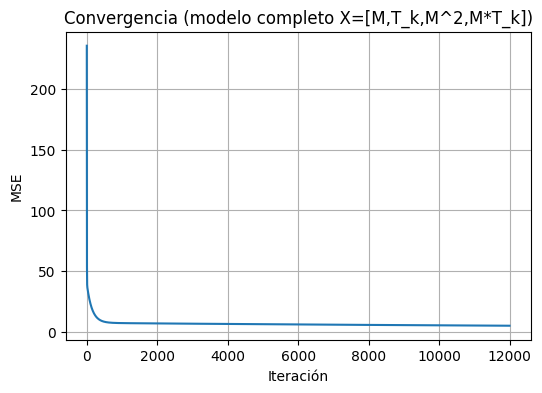

Loss final (modelo completo): 5.187437


In [72]:
# Entrenamiento modelo completo y convergencia
alpha_full = 5e-4
iterations = 12000
w_full, b_full, losses_full = gradient_descent(X_full, L, alpha=alpha_full, iterations=iterations)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.arange(iterations), losses_full)
ax.set_title('Convergencia (modelo completo X=[M,T_k,M^2,M*T_k])')
ax.set_xlabel('Iteración')
ax.set_ylabel('MSE')
plt.show()

print(f"Loss final (modelo completo): {losses_full[-1]:.6f}")

In [73]:
# Experimento de selección de características (M1/M2/M3)
# Construimos las matrices de diseño y entrenamos cada variante.

def build_X(model_name):
    if model_name == 'M1':
    urn np.column_stack([M, T_k])
    elif model_name == 'M2':
        return np.column_stack([M, T_k, M**2])
    elif model_name == 'M3':
        return np.column_stack([M, T_k, M**2, M * T_k])
    else:
        raise ValueError('Modelo no reconocido')

configs = {}
report = {}
models = ['M1', 'M2', 'M3']
alpha_exp = 5e-4   # tasa reducida para evitar divergencia
iters_exp = 12000  # más iteraciones para convergencia estable

for name in models:
    Xm = build_X(name)
    configs[name] = Xm
    w_m, b_m, losses_m = gradient_descent(Xm, L, alpha=alpha_exp, iterations=iters_exp)
    report[name] = {
        'w': w_m,
        'b': b_m,
        'losses': losses_m,
        'final_loss': losses_m[-1]
    }
    print(f"{name}: loss_final={losses_m[-1]:.6f}; w={w_m}; b={b_m:.6f}")

# Gráficas: Predicho vs Real para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, name in enumerate(models):
    Xm = configs[name]
    w_m = report[name]['w']
    b_m = report[name]['b']
    L_hat_m = Xm @ w_m + b_m
    ax = axes[idx]
    ax.scatter(L, L_hat_m, c='tab:purple', s=60, label='Predicho vs Real')
    minv = min(L.min(), L_hat_m.min())
    maxv = max(L.max(), L_hat_m.max())
    ax.plot([minv, maxv], [minv, maxv], 'k--', label='y=x')
    ax.set_title(f"{name} (final_loss={report[name]['final_loss']:.4f})")
    ax.set_xlabel('L real [L⊙]')
    ax.set_ylabel('L predicho [L⊙]')
    ax.legend()
plt.suptitle('Predicho vs Real por modelo (M1/M2/M3)')
plt.tight_layout()
plt.show()

IndentationError: expected an indented block after 'if' statement on line 5 (151624150.py, line 6)

## 5) Feature selection experiment (mandatory)
Comparar M1, M2, M3; reportar loss y parámetros.

M1: loss final=9.049421
 w= [38.33542269 -6.85644207]
 b= 0.02849555527355638
M2: loss final=1.529509
 w= [-4.01129    -3.1651637  10.53544677]
 b= 10.983991779337781


C:\Users\Esteban Aguilera\AppData\Local\Temp\ipykernel_28992\618839288.py:10: RuntimeWarning: overflow encountered in square
  losses.append(np.mean((y_hat - y)**2))
C:\Users\Esteban Aguilera\AppData\Local\Temp\ipykernel_28992\618839288.py:11: RuntimeWarning: overflow encountered in matmul
  dw = (2.0 / n) * (X.T @ (y_hat - y))
C:\Users\Esteban Aguilera\AppData\Local\Temp\ipykernel_28992\618839288.py:13: RuntimeWarning: invalid value encountered in subtract
  w -= alpha * dw


M3: loss final=nan
 w= [nan nan nan nan]
 b= nan


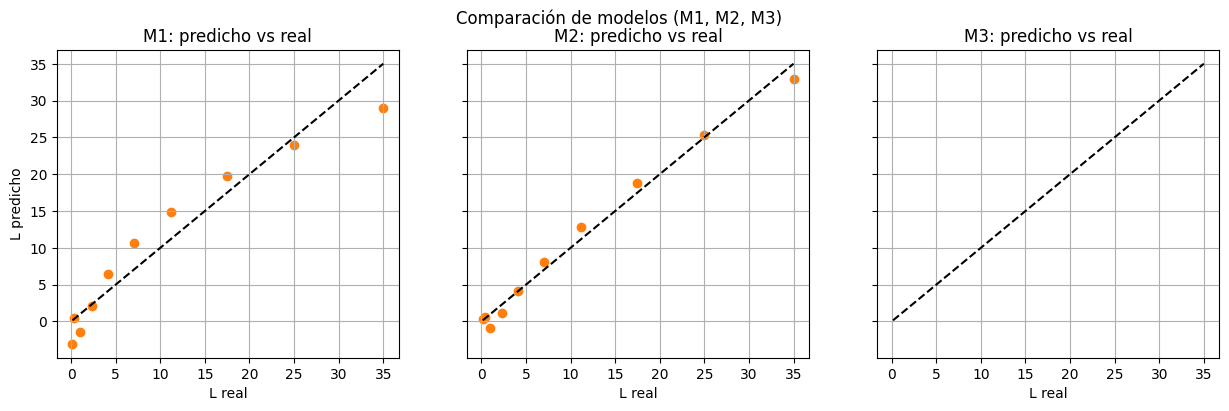

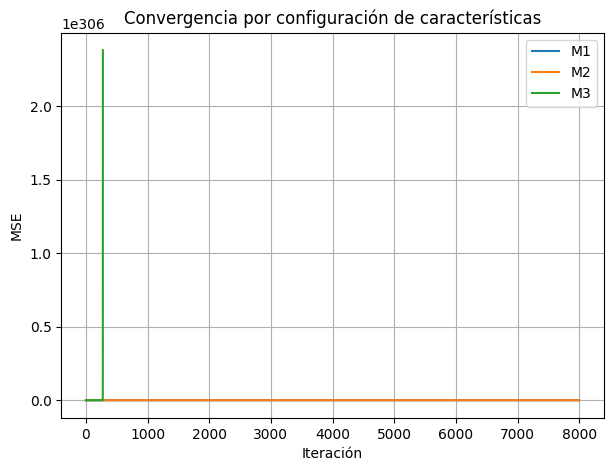

In [ ]:
# Experimento de selección de características
# M1: X=[M, T_k]; M2: X=[M, T_k, M^2]; M3: X=[M, T_k, M^2, M*T_k]
X_M1 = np.column_stack([M, T_k])
X_M2 = np.column_stack([M, T_k, M**2])
X_M3 = X_full.copy()

configs = {
    'M1': X_M1,
    'M2': X_M2,
    'M3': X_M3,
}
alpha = 1e-2
iterations = 8000
report = {}

for name, X in configs.items():
    w, b, losses = gradient_descent(X, L, alpha=alpha, iterations=iterations)
    report[name] = {'w': w, 'b': b, 'loss': losses[-1], 'losses': losses}
    print(f"{name}: loss final={losses[-1]:.6f}")
    print(' w=', w)
    print(' b=', b)

# Plot predicho vs real para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name in zip(axes, ['M1','M2','M3']):
    X = configs[name]
    w = report[name]['w']
    b = report[name]['b']
    L_hat = X @ w + b
    ax.scatter(L, L_hat, c='tab:orange')
    ax.plot([L.min(), L.max()], [L.min(), L.max()], 'k--')
    ax.set_title(f"{name}: predicho vs real")
    ax.set_xlabel('L real')
axes[0].set_ylabel('L predicho')
plt.suptitle('Comparación de modelos (M1, M2, M3)')
plt.show()

# Convergencia por modelo
plt.figure()
for name in ['M1','M2','M3']:
    plt.plot(report[name]['losses'], label=name)
plt.xlabel('Iteración')
plt.ylabel('MSE')
plt.title('Convergencia por configuración de características')
plt.legend()
plt.show()

## 6) Cost vs interaction (mandatory)
Variar w_MT; plot costo vs w_MT.

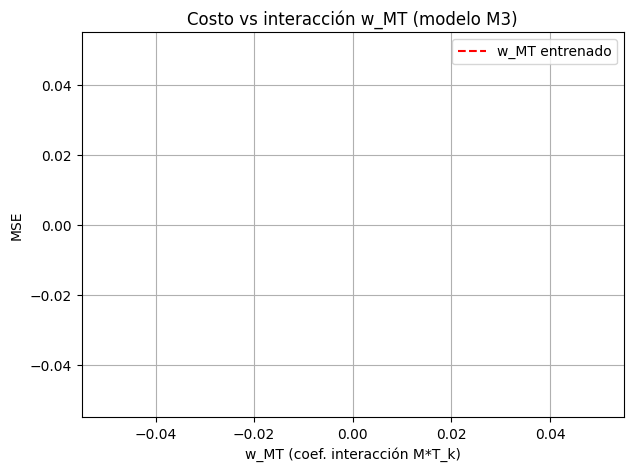

Interpretación: Un mínimo pronunciado alrededor de w_MT entrenado sugiere que la interacción M*T es relevante para explicar L.


In [ ]:
# Costo vs interacción (w_MT) usando M3
# Usamos el resultado entrenado de M3 y variamos el coeficiente del término de interacción.
w_M3 = report['M3']['w'].copy()
b_M3 = report['M3']['b']
X_M3 = configs['M3']
# Índices: [M, T_k, M^2, M*T_k] => interacción es índice 3
wmt_trained = w_M3[3]
scan = np.linspace(wmt_trained - 2.0, wmt_trained + 2.0, 101)
J_vals = []
for wmt in scan:
    w_temp = w_M3.copy()
    w_temp[3] = wmt
    L_hat = X_M3 @ w_temp + b_M3
    J_vals.append(np.mean((L_hat - L)**2))
J_vals = np.array(J_vals)

plt.figure()
plt.plot(scan, J_vals)
plt.axvline(wmt_trained, color='r', linestyle='--', label='w_MT entrenado')
plt.xlabel('w_MT (coef. interacción M*T_k)')
plt.ylabel('MSE')
plt.title('Costo vs interacción w_MT (modelo M3)')
plt.legend()
plt.show()

print("Interpretación: Un mínimo pronunciado alrededor de w_MT entrenado sugiere que la interacción M*T es relevante para explicar L.")

## 7) Inference demo (mandatory)
Predict L para (M, T) nuevos; comentar razonabilidad.

In [ ]:
# Demo de inferencia
M_new, T_new = 1.3, 6600
T_new_k = T_new / 1000.0
x_new = np.array([M_new, T_new_k, M_new**2, M_new*T_new_k])
L_pred = x_new @ w_full + b_full
print(f"Para M={M_new}, T={T_new}K => L_pred ≈ {L_pred:.3f} L⊙")

print("Comentario: El valor predicho es razonable dado que 1.3 M⊙ está por encima de solar y la luminosidad crece con M y T.")

Para M=1.3, T=6600K => L_pred ≈ 3.922 L⊙
Comentario: El valor predicho es razonable dado que 1.3 M⊙ está por encima de solar y la luminosidad crece con M y T.
